In [ ]:
import numpy as np

grid = np.array([
    [0,0,0,1,0],
    [1,1,0,1,0],
    [0,0,0,0,0],
    [0,1,1,1,0],
    [0,0,0,0,0]
])

print(grid)

[[0 0 0 1 0]
 [1 1 0 1 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 0 0 0 0]]


[[0 0 0 1 0]
 [1 1 0 1 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 0 0 0 0]]


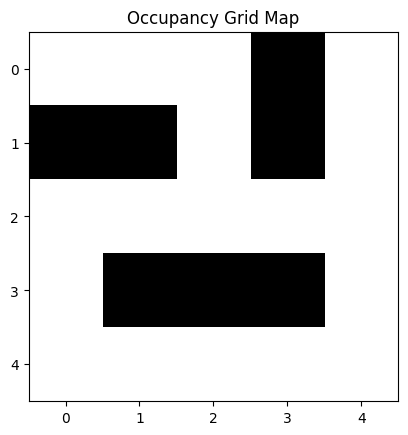

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

grid = np.array([
    [0,0,0,1,0],
    [1,1,0,1,0],
    [0,0,0,0,0],
    [0,1,1,1,0],
    [0,0,0,0,0]
])

print(grid)

plt.imshow(grid, cmap='gray_r')
plt.title("Occupancy Grid Map")
plt.show()

Start: (0, 0)
Goal: (4, 4)


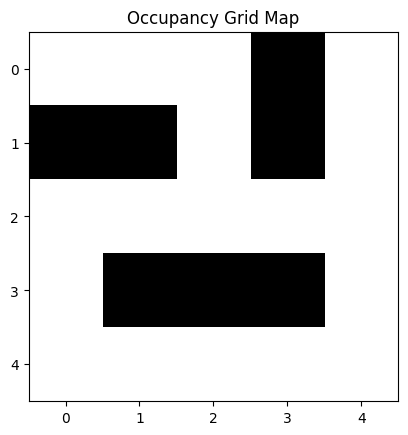

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

grid = np.array([
    [0,0,0,1,0],
    [1,1,0,1,0],
    [0,0,0,0,0],
    [0,1,1,1,0],
    [0,0,0,0,0]
])

start = (0,0)
goal = (4,4)

print("Start:", start)
print("Goal:", goal)

plt.imshow(grid, cmap='gray_r')
plt.title("Occupancy Grid Map")
plt.show()

In [ ]:
import heapq

def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def astar(grid, start, goal):

    rows, cols = grid.shape

    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score = {start: 0}

    while open_set:

        _, current = heapq.heappop(open_set)

        if current == goal:

            path = []

            while current in came_from:
                path.append(current)
                current = came_from[current]

            path.append(start)

            return path[::-1]

        for dx, dy in [(0,1), (1,0), (0,-1), (-1,0)]:

            nx = current[0] + dx
            ny = current[1] + dy

            if 0 <= nx < rows and 0 <= ny < cols:

                if grid[nx][ny] == 0:

                    tentative = g_score[current] + 1

                    if (nx, ny) not in g_score or tentative < g_score[(nx, ny)]:

                        came_from[(nx, ny)] = current
                        g_score[(nx, ny)] = tentative

                        f_score = tentative + heuristic((nx, ny), goal)

                        heapq.heappush(open_set, (f_score, (nx, ny)))

    return []


In [ ]:
path = astar(grid, start, goal)

print("Shortest Path:")
print(path)

Shortest Path:
[(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]


In [ ]:
grid[2][2] = 1

In [ ]:
new_path = astar(grid,start,goal)

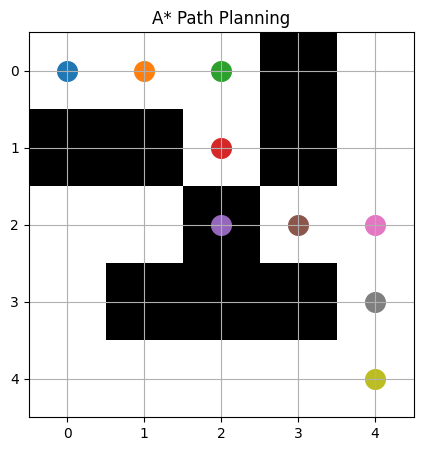

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.imshow(grid, cmap='gray_r')

for p in path:
    plt.scatter(p[1], p[0], s=200)

plt.title("A* Path Planning")
plt.grid(True)
plt.show()

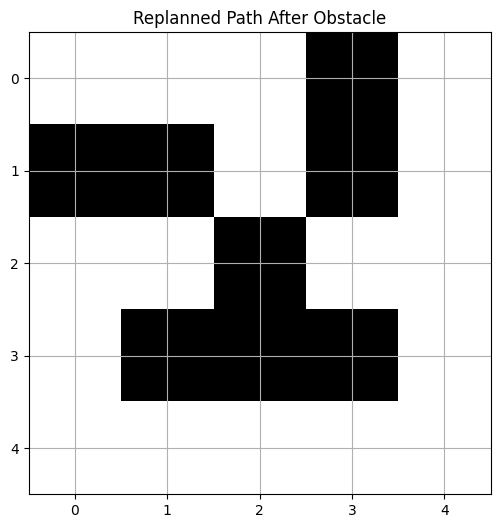

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(grid, cmap='gray_r')

for p in new_path:
    plt.plot(p[1], p[0], 'ro', markersize=10)

plt.title("Replanned Path After Obstacle")
plt.grid(True)
plt.show()

In [ ]:
grid[2][2] = 1
print(grid)

[[0 0 0 1 0]
 [1 1 0 1 0]
 [0 0 1 0 0]
 [0 1 1 1 0]
 [0 0 0 0 0]]


In [ ]:
print(new_path)

[]
